# ARIMA 

## Overview
**ARIMA** (AutoRegressive Integrated Moving Average) is a statistical model used for time series forecasting. It combines three components:

  1. **AR (Auto Regressive)** - correlation to past values
  2. **I (Integrated)** - differencing to make time series stationary 
  3. **MA (Moving Average)** - past errors  

It is a statistical model used to forecast future values based on the influence of the past values on the present values.  

# Packages to install
conda install conda-forge::scikit-learn  
conda install -c conda-forge pmdarima

# Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error)
from sklearn.model_selection import ParameterGrid

# Load and check stationarity 

ARIMA requires the time series to be **stationary** (constant mean and variance over time).  

We use the the **Augmented Dickey_Full (ADF)** test check if the timeseries is stationary.  
- The H0 (null hypothesis): the time series is NOT stationary.   
- The H1 (alternative hypthesis): the time series is stationary  
- If **p-value <= 0.05**, reject H0 and treat the time sereies as stationary

H_0 = timeseries is not stationary.
H_1 = timeseries is stationary.

In [7]:
#import the dataset and set the index to time 
df = pd.read_csv('time_series_exploration/AUS_monthly_beer_production.csv', parse_dates=['time'], index_col='time')

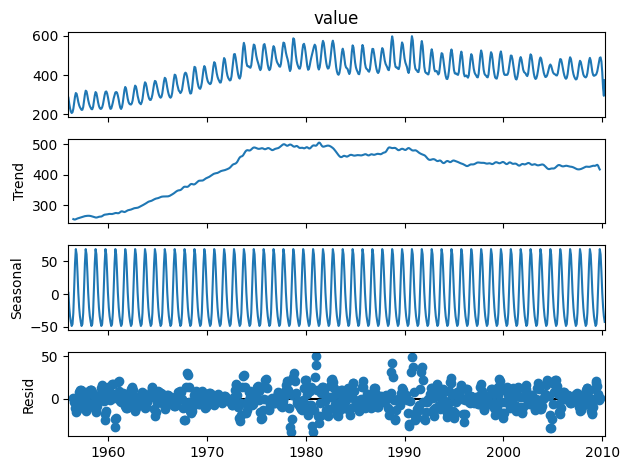

In [8]:
# plot the data to check if the time series is stationary - use seasonal_decompose
decomposition = seasonal_decompose(df['value'], model='additive', period=12)
decomposition.plot()
plt.show()

In [9]:
# check stationarity with ADF test

def check_stationarity(df): 
  result = adfuller(df)
  if result[1] > 0.05:
    print("The time series is not stationary")
  else:
    print("The time series is stationary")

check_stationarity(df['value'])

The time series is not stationary


# ARIMA model

In statsmodels. ARIMA is denoted as (p, d, q), where:
- **p** = number of lags or autoregressive terms. It refers to the number of past observations that directly infleunce the current value.   
The  number is identified by **PACF**  

- **d**
    * number of differentiating. It represents the number of differences need to make the time series stationsry. Usually: 0 ≤ d ≤ 2
    * Basically differentiation is bringing data around mean.
  
- **q** = order of moving average values. It represents the number of lagged forecast errors.  
   

Package that automatically discover the optinmal number of ARIMA's parameters: [auto_arima](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)

**Key assumptions**:
1. The time series can be made stationary through differencing
2. Past values and past errors contain information useful for forecasting
3. The relationship between past and present is linear

## Train/Test Split

We split the data into 70% training and 30% testing sets.


In [10]:
# split the dataset in training and testing
train, test = df.iloc[:int(len(df)*0.7)], df.iloc[int(len(df)*0.7):]
train, test

(                 value
 time                  
 1956-01-01  284.000000
 1956-02-01  253.444206
 1956-03-01  230.185302
 1956-04-01  213.000000
 1956-05-01  205.676860
 ...                ...
 1993-08-01  443.237318
 1993-09-01  485.105528
 1993-10-01  512.000000
 1993-11-01  508.769037
 1993-12-01  483.625271
 
 [456 rows x 1 columns],
                  value
 time                  
 1994-01-01  449.000000
 1994-02-01  417.337447
 1994-03-01  395.598884
 1994-04-01  381.000000
 1994-05-01  379.650897
 ...                ...
 2009-12-01  469.744786
 2010-01-01  414.000000
 2010-02-01  331.991312
 2010-03-01  293.894955
 2010-04-01  374.000000
 
 [196 rows x 1 columns])

## Differencing

If the series is not stationary, we apply **differencing** to remove trends.

**Important**: We only difference the training data to avoid data leakage. The ARIMA model will handle differencing internally via the `d` parameter.

In [11]:
# First difference 
train_diff = train.diff().dropna()
train_diff

# Check stationarity after differencing - use check stationarity function
check_stationarity(train_diff)

The time series is stationary


**NOTE** It is already stationary. `q` then should be 1.

## Identify ARIMA parameters p and q  
- p = number of lags 
- d = number of differencing  
- q = order of moving average

We use ACF and PACF plots on the **differenced** data to identify the `p` and `q` parameters:

| Plot | Identifies | How to read |
|------|------------|-------------|
| **ACF** | **q** (MA order) | Count significant lags before cutoff |
| **PACF** | **p** (AR order) | Count significant lags before cutoff |



**How to read the plots**:
- Count significant lags (bars exceeding the blue shaded confidence interval)
- The lag where the plot cuts off suggests the order

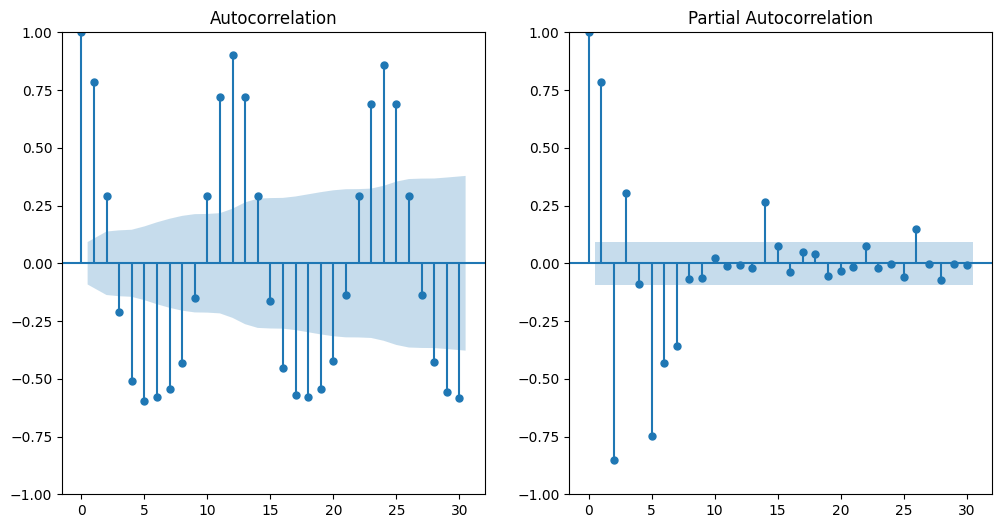

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# q - ACF [df, lags, ax=plt.gca()]
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plot_acf(train_diff['value'], ax=plt.gca(), lags=30)

#p - PACF
plt.subplot(1,2,2)
plot_pacf(train_diff['value'], ax=plt.gca(), lags=30)
plt.show()

**NOTE** This above is to determine the `p` value. Let's try it with 8, 15 and 25 respectively, based on the right plot.

## Fit ARIMA model and check summary of the model

Based on the ACF/PACF analysis, we select the parameters (p, d, q) and fit the model.

**Important**: Pass the **original** (non-differenced) training data to the ARIMA model. The model handles differencing internally via the `d` parameter.

**model results**  
In statsmodels. the ARIMA model is a special case of the more general 
**SARIMAX** (Seasonal ARIMA with eXogenous variable)

The SARIMAX model has four models under its hat: 
ARIMA
SARIMA
ARIMAX
SARIMAX

In [13]:
# fit ARIMA model
# ARIMA(df, order(p, d, q))
model = ARIMA(train['value'], order=(25,1,1))
model = model.fit()

# Display summary of the model
print(model.summary())

/home/balin/repos/ceu/ceu-time-series-forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/balin/repos/ceu/ceu-time-series-forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/balin/repos/ceu/ceu-time-series-forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/balin/repos/ceu/ceu-time-series-forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  456
Model:                ARIMA(25, 1, 1)   Log Likelihood                -985.816
Date:                Tue, 27 Jan 2026   AIC                           2025.631
Time:                        14:48:58   BIC                           2136.879
Sample:                    01-01-1956   HQIC                          2069.458
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9007      0.825      1.092      0.275      -0.716       2.518
ar.L2          0.3840      1.341      0.286      0.775      -2.243       3.011
ar.L3         -2.0409      0.663     -3.078      0.0

## Forcasting  and model evaluation

We evaluate the model using common metrics:

| Metric | Description | How to interpret |
|--------|-------------|------------------|
| **MAE** | Mean Absolute Error - average absolute difference | Lower = better. Easy to understand as "average error" |
| **RMSE** | Root Mean Squared Error - penalizes larger errors | Lower = better. If RMSE >> MAE, large outlier errors exist |
| **MAPE** | Mean Absolute Percentage Error - percentage error | <10% = excellent,  10-20% = good,  20-50% = acceptable, >50% = poor |


In [14]:
# Forecasting
# .forecast(steps = how many values in the future we want to predict We forecast the same length of test dataset (66))
forecast = model.forecast(steps=len(test))

In [15]:
# Function to plot results and evaluate model performance
def model_assessment(train, test, predictions, chart_title):
  """Plot train/test/prediction series and print common error metrics.

  Args:
      train (pd.Series): In-sample target used to fit the model.
      test (pd.Series): Holdout target used to evaluate the forecast.
      predictions (pd.Series or np.ndarray): Forecast aligned to `test` index.
      chart_title (str): Short label for the chart (e.g., model name).

  Notes
  -----
  * MAE = mean(|y - ŷ|)
  * RMSE = sqrt(mean((y - ŷ)^2))
  * MAPE = mean(|(y - ŷ)/y|). Use with care when y can be 0.
  """
  # Set the size of the plot to 10 inches by 4 inches
  plt.figure(figsize = (10,4))
  # Plot the train, test, and forecast data
  plt.plot(train, label = 'Train')
  plt.plot(test, label = 'Test')
  plt.plot(predictions, label = "Forecast")
  # add title and legend to the plot
  plt.title(f"Train, Test and Predictions with {chart_title}")
  plt.legend()
  plt.show()

  # Calculating the MAE, RMSE, and MAPE
  mae = mean_absolute_error(test, predictions)
  rmse = root_mean_squared_error(test, predictions)
  mape = mean_absolute_percentage_error(test, predictions)

  # Print the calculated error metrics
  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {100 * mape:.2f} %")

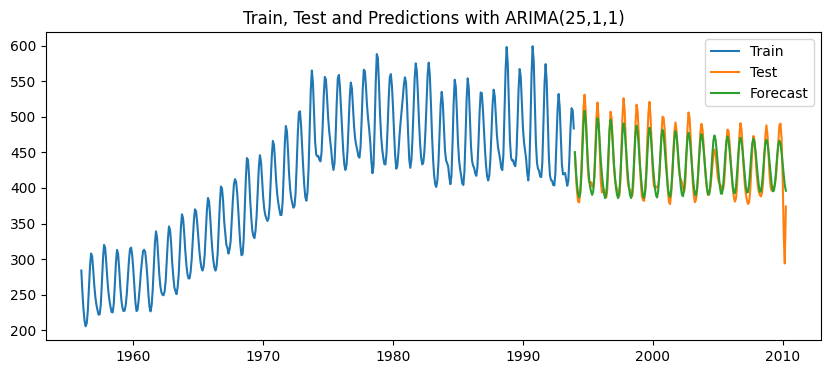

The MAE is 11.69
The RMSE is 16.65
The MAPE is 2.75 %


In [16]:
# use model_assessment function 

model_assessment(train['value'], test['value'], forecast, "ARIMA(25,1,1)")

**NOTE** It can be seen on the graph that the prediction quality decreases going down from `25` to towards `8`.

## Summary

### ARIMA Workflow:

1. **Load and visualize** the time series data
2. **Split** into training (70%) and testing (30%) sets
3. **Check stationarity** using ADF test
4. **Difference** the training data if not stationary
5. **Analyze ACF/PACF** on differenced data to find p and q
6. **Fit ARIMA** model on original training data with (p, d, q)
7. **Forecast** and evaluate the model

### Key Points:

- Only difference the **training data** for ACF/PACF analysis
- Pass **original data** to ARIMA model (it handles differencing via `d`)
- Use **PACF** for AR order (p) and **ACF** for MA order (q)
- Lower **AIC/BIC** indicates better model fit

# SARIMA model
SARIMA extends ARIMA model by adding season component

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# s=12 for monthly data with yearly seasonality
model = SARIMAX(train['value'], order=(8,1,1), seasonal_order=(8,1,1,12))
model = model.fit()

/home/balin/repos/ceu/ceu-time-series-forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/balin/repos/ceu/ceu-time-series-forecasting/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/balin/repos/ceu/ceu-time-series-forecasting/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [18]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  456
Model:             SARIMAX(8, 1, 1)x(8, 1, 1, 12)   Log Likelihood                -909.275
Date:                            Tue, 27 Jan 2026   AIC                           1856.551
Time:                                    14:52:04   BIC                           1934.328
Sample:                                01-01-1956   HQIC                          1887.225
                                     - 12-01-1993                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5920      0.100     15.990      0.000       1.397       1.787
ar.L2         -0.7677      0.151     -5.070      0.000      -1.064      -0.471
ar.L3         -1.4236      0.086    -16.614      0.000      -1.592      -1.256
ar.L4          2.0469      0.142     14.433      0.000       1.769       2.325
ar.L5         -0.8149      0.158     -5.156      0.000      -1.125      -0.505
ar.L6         -0.7826      0.075    -10.366      0.000      -0.931      -0.635
ar.L7          0.9192      0.094      9.802      0.000       0.735       1.103
ar.L8         -0.3869      0.059     -6.524      0.000      -0.503      -0.271
ma.L1          0.0432      0.114      0.379      0.705      -0.180       0.267
ar.S.L12       0.2146      0.112      1.914      0.056      -0.005       0.434
ar.S.L24       0.0814      0.092      0.885      0.376      -0.099       0.262
ar.S.L36       0.1067      0.088      1.207      0.227      -0.067       0.280
ar.S.L48       0.1071      0.078      1.377      0.168      -0.045       0.259
ar.S.L60       0.0270      0.063      0.428      0.668      -0.096       0.150
ar.S.L72       0.0512      0.071      0.718      0.473      -0.089       0.191
ar.S.L84       0.0858      0.056      1.528      0.126      -0.024       0.196
ar.S.L96      -0.0146      0.055     -0.264      0.792      -0.123       0.094
ma.S.L12      -0.9549      0.112     -8.500      0.000      -1.175      -0.735
sigma2         3.3720      0.205     16.455      0.000       2.970       3.774
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                23.02
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               1.55   Skew:                             0.19
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

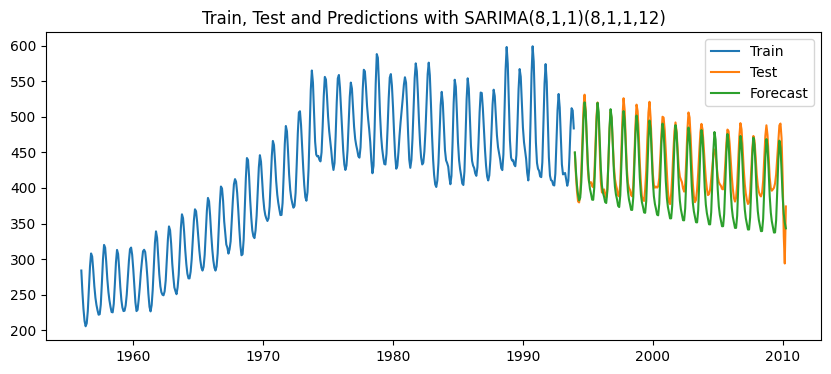

The MAE is 24.58
The RMSE is 28.82
The MAPE is 5.87 %


In [19]:
forecast_period = 2
forecast_sarima = model.forecast(steps=len(test))
model_assessment(train['value'], test['value'], forecast_sarima, "SARIMA(8,1,1)(8,1,1,12)")

In [20]:
observed = train.tail(forecast_period)

mae = mean_absolute_error(observed, forecast_sarima[:forecast_period])
rmse = root_mean_squared_error(observed, forecast_sarima[:forecast_period])
mape = mean_absolute_percentage_error(observed, forecast_sarima[:forecast_period])

print(f"MAE for last {forecast_period} months: {mae:.2f}")
print(f"RMSE for last {forecast_period} months: {rmse:.2f}")
print(f"MAPE for last {forecast_period} months: {100 * mape:.2f} %")

MAE for last 2 months: 59.90
RMSE for last 2 months: 59.91
MAPE for last 2 months: 12.08 %
